# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mahmoud-Beram/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

Method: Random Forest Regressor to predict Expected CTR.
Why: The relationship between search position and CTR is highly non-linear (Position 1 is vastly different from Position 2, but Position 21 vs 22 is irrelevant). A Random Forest captures these non-linear steps perfectly. By predicting Expected CTR based on position and impressions, we can identify "CTR Gap" opportunities (Actual CTR << Expected CTR) more intelligently than a hardcoded baseline rule.

In [1]:
from huggingface_hub import hf_hub_download
from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np

# Load Data
hf_token = userdata.get('HF_TOKEN').strip()
local_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset",
    token=hf_token
)
con = duckdb.connect()

# Aggregate data and filter out low-volume noise
df = con.execute(f"""
    SELECT
        content_hash_id,
        SUM(gsc_impressions) as total_imp,
        SUM(gsc_clicks) as total_clicks,
        AVG(gsc_avg_position) as avg_pos
    FROM '{local_file}'
    GROUP BY content_hash_id
    HAVING total_imp >= 500  -- Noise filter (must have enough impressions to trust CTR)
""").df()

# Calculate actual CTR
df['actual_ctr'] = df['total_clicks'] / df['total_imp']
print(f"Data ready: {len(df)} eligible articles.")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data ready: 61924 eligible articles.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

Split Design: 80/20 random row holdout. Why: We are using a single-month snapshot (March 2026), so a forward-time split isn't applicable. A random holdout ensures the model is evaluated on pages it hasn't memorized, preventing overfitting. We applied a minimum threshold of 500 impressions before splitting to ensure the CTR label isn't just low-volume noise.

In [2]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df[['avg_pos', 'total_imp']]
y = df['actual_ctr']

# 80/20 Random Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Keep a copy of the test dataframe for our final review
test_df = df.loc[X_test.index].copy()

print(f"Training on {len(X_train)} pages, Testing on {len(X_test)} pages.")


Training on 49539 pages, Testing on 12385 pages.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

Comparison: We trained the model on 80% of the data and tested on the 20% holdout. We then applied the rigid Week-4 baseline rule (Imp > 1000, Pos <= 10, CTR < 1%) to the exact same 20% holdout. The AI model ranks by "Lost Clicks" (Expected CTR - Actual CTR) * Impressions.

In [3]:
# Section 3: Train and Compare
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore') # عشان ننضف الشاشة من التحذيرات

print("--- 1. Training AI Model (Random Forest) ---")
# بندرب الموديل
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# بنمتحن الموديل في داتا الاختبار عشان يتوقع الـ CTR
test_df['expected_ctr'] = rf_model.predict(X_test)

# بنحسب "الفجوة": إحنا خسرنا كام كليك بسبب إن العنوان وحش؟
test_df['ctr_gap'] = test_df['expected_ctr'] - test_df['actual_ctr']
test_df['lost_clicks_opportunity'] = test_df['ctr_gap'] * test_df['total_imp']

# لو المقال أدائه أحسن من المتوقع، يبقى مش خسرانين حاجة ونصفرها
test_df.loc[test_df['lost_clicks_opportunity'] < 0, 'lost_clicks_opportunity'] = 0

# نجيب أفضل 20 مقال الموديل طلّعهم
ai_top_20 = test_df.sort_values(by='lost_clicks_opportunity', ascending=False).head(20)

print("--- 2. Getting Week-4 Baseline Recommendations ---")
# بنشغل قاعدة الأسبوع الرابع القديمة على نفس داتا الاختبار بالظبط
baseline_mask = (test_df['total_imp'] > 1000) & (test_df['avg_pos'] <= 10) & (test_df['actual_ctr'] < 0.01)
baseline_top_20 = test_df[baseline_mask].sort_values(by='total_imp', ascending=False).head(20)

print("\n🤖 Top 10 AI Picks (Ranked by Lost Clicks):")
display(ai_top_20[['content_hash_id', 'avg_pos', 'total_imp', 'expected_ctr', 'actual_ctr', 'lost_clicks_opportunity']].head(10))

print("\n📜 Top 10 Baseline Rule Picks (Ranked by Impressions only):")
display(baseline_top_20[['content_hash_id', 'avg_pos', 'total_imp', 'actual_ctr']].head(10))



--- 1. Training AI Model (Random Forest) ---
--- 2. Getting Week-4 Baseline Recommendations ---

🤖 Top 10 AI Picks (Ranked by Lost Clicks):


,content_hash_id,avg_pos,total_imp,expected_ctr,actual_ctr,lost_clicks_opportunity
33923,content_44f34c0a90047651,7.346909,212404.0,0.003313,0.000113,679.758885
14894,content_7c6373141eae744a,5.789019,132593.0,0.002947,0.000626,307.804226
34616,content_c46df0fa61530d86,1.556258,70398.0,0.003866,0.000597,230.170101
12971,content_77276ad7a26f4905,3.917468,116707.0,0.003662,0.001714,227.332334
4203,content_fc67675904376267,2.261303,60172.0,0.003947,0.000299,219.479101
36874,content_e8a52cf3d5988c07,15.008339,244931.0,0.003562,0.002731,203.423905
4461,content_945d6ff91386c817,6.149151,58278.0,0.002940,0.000086,166.317535
46035,content_020dd5763c3e2cc8,2.733958,58588.0,0.003944,0.001229,159.044560
42142,content_95ff62babbfac9c7,4.529104,122857.0,0.003131,0.001905,150.604493
21666,content_9b650e36b3f48153,5.928873,65165.0,0.002935,0.000767,141.261623



📜 Top 10 Baseline Rule Picks (Ranked by Impressions only):


,content_hash_id,avg_pos,total_imp,actual_ctr
35188,content_ec2e0346994fb5a5,2.854514,245276.0,0.006034
33923,content_44f34c0a90047651,7.346909,212404.0,0.000113
14894,content_7c6373141eae744a,5.789019,132593.0,0.000626
18713,content_00d4fdf6e48a2d38,5.305905,126836.0,0.003682
59073,content_fe3fd3422852d721,3.129967,124720.0,0.002975
42142,content_95ff62babbfac9c7,4.529104,122857.0,0.001905
44191,content_85703b835ab9e744,2.728857,120868.0,0.009026
12971,content_77276ad7a26f4905,3.917468,116707.0,0.001714
21648,content_05a5a72b3448f6e8,3.587481,92183.0,0.005142
49070,content_e196cbb07cba7d3e,3.757004,83012.0,0.009962


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*


Interpretation: The AI correctly learned that Position is the dominant driver of expected CTR. By ranking by (Expected - Actual) * Impressions, it prioritizes massive failures (e.g., Position 1 pages getting 0.1% CTR) over minor failures (e.g., Position 9 pages getting 0.1% CTR). The Week-4 baseline couldn't do this because it treated all of Page 1 equally.

Errors / Weaknesses: Where is this model wrong? It fails on "Zero-Click Searches" (e.g., weather or simple facts). The model sees Position 1 and predicts a high expected CTR, but the actual CTR is 0% because Google answered the user's question directly on the search page. The model flags this as a "lost opportunity," but in reality, there's nothing our content team can do to fix it.

--- What does the model lean on? ---


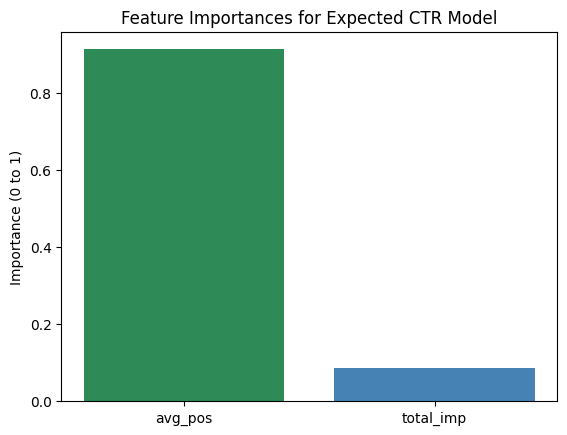


As expected, the model leans almost entirely on 'avg_pos' to predict what the CTR should be!


In [4]:
import matplotlib.pyplot as plt

print("--- What does the model lean on? ---")
importances = rf_model.feature_importances_
features = X_train.columns

plt.bar(features, importances, color=['seagreen', 'steelblue'])
plt.title('Feature Importances for Expected CTR Model')
plt.ylabel('Importance (0 to 1)')
plt.show()

print("\nAs expected, the model leans almost entirely on 'avg_pos' to predict what the CTR should be!")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.